In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_excel('https://www.robertohincapie.com/data/datos_viviendas1.xlsx')
data.head()

,Cod_Inmueble,Barrio,Precio,Antiguedad,Area_Construida,Area_Privada,Valor_Admon,Parqueaderos,Habitaciones,Baños,Estrato
0,11318-M3058418,Castropol/Poblado,518000000,Entre 0 y 5 años,110.0,122.0,377000.0,1,4,3,6.0
1,11318-M3021864,Belen/Malibu,382000000,Entre 0 y 5 años,64.0,64.0,190000.0,1,2,3,5.0
2,11318-M3058231,Laureles,845000000,Entre 0 y 5 años,137.0,137.0,530000.0,2,3,4,5.0
3,13155-M3070155,EL POBLADO DE SANTA MARIA DE LOS ANGELES,705000000,Entre 0 y 5 años,123.0,123.0,600000.0,2,3,2,6.0
4,2364-M3070004,El Tesoro,1250000000,Remodelado,232.0,232.0,680000.0,2,3,5,6.0


<Axes: >

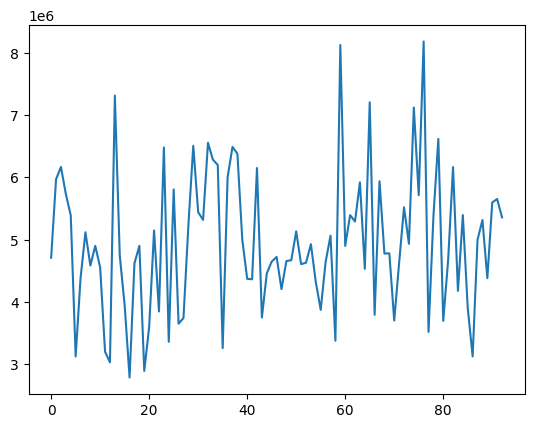

In [ ]:
#Vamos a calcular una nueva columna que tiene el precio por metro cuadrado
data['ValorPorMetroCuadrado']=data['Precio']/data['Area_Construida']
data['ValorPorMetroCuadrado'].plot()

In [ ]:
#Reemplazo de los barrios. Este es en cierta forma un mapeo:
#Cada valor de barrio lo cambiamos por otro de acuerdo con el diccionario que lo define.
data['Barrio']=data['Barrio'].replace({'Castropol/Poblado':'Poblado','Belen/Malibu':'Belén','Laureles':'Laureles','EL POBLADO DE SANTA MARIA DE LOS ANGELES':'Poblado',
'El Tesoro':'Poblado','san Germán':'Robledo','EL TESORO':'Poblado','EL PESEBRE':'Robledo','EL POBLADO':'Poblado','Conquistadores':'Conquistadores',
'LOS BALSOS':'Poblado','La Calera':'Poblado','Calasanz':'Calasanz','BELEN RODEO ALTO':'Belén','El Poblado':'Poblado','Castropol':'Poblado',
'Ciudad Del Río':'Poblado','poblado':'Poblado','La Candelaria':'Centro', 'Loma De Los Bernal':'Belén', 'LA LINDE':'Poblado',
'San Lucas':'Poblado', 'Los Balsos':'Poblado', 'La Pilarica':'Robledo', 'CAMPESTRE':'Poblado', 'Poblado':'Poblado','ALTOS DEL POBLADO':'Poblado',
'lalinde':'Poblado','Balsos':'Poblado', 'LA FLORIDA':'Poblado','LOS BALSOS NO 1':'Poblado', 'Las Palmas':'Poblado', 'Loma del Indio':'Poblado',
'POBLADO LA FRONTERA':'Poblado', 'Conquistadores/occidente':'Conquistadores', 'Los Parra':'Poblado','Belen':'Belén', 'Medellín':'Medellín',
'Los colores':'Los Colores', 'Sabaneta':'Sabaneta','EL POBLADO LA LINDE':'Poblado', 'Los Balsos - El Poblado':'Poblado', 'LA AMERICA':'La América',
'Santa Maria De Los':'Poblado', 'LAURELES':'Laureles'})
data['Barrio'].unique()

array(['Poblado', 'Belén', 'Laureles', 'Robledo', 'Conquistadores',
       'Calasanz', 'Centro', 'Medellín', 'Los Colores', 'Sabaneta',
       'La América'], dtype=object)

In [ ]:
#Convirtamos la columna de antigüedad en un número, para poder graficar el valor por metro cuadrado con respecto a la antigüedad de la propiedad.
data['Antiguedad'].unique()

array(['Entre 0 y 5 años', 'Remodelado', 'Entre 10 y 20 años',
       'Entre 5 y 10 años', 'Más de 20 años'], dtype=object)

<ipython-input-5-5f431b557aa7>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['AntiguedadNum']=data['Antiguedad'].replace({'Entre 0 y 5 años':2.5, 'Remodelado':0, 'Entre 10 y 20 años':15,


Text(0.5, 1.0, 'Valor por metro cuadrado respecto a la antigüedad')

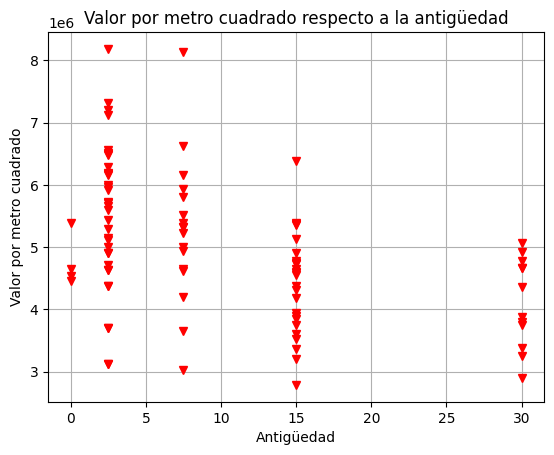

In [ ]:
data['AntiguedadNum']=data['Antiguedad'].replace({'Entre 0 y 5 años':2.5, 'Remodelado':0, 'Entre 10 y 20 años':15,
       'Entre 5 y 10 años':7.5, 'Más de 20 años':30})
#data
plt.plot(data['AntiguedadNum'], data['ValorPorMetroCuadrado'],'vr')
plt.xlabel('Antigüedad')
plt.ylabel('Valor por metro cuadrado')
plt.grid()
plt.title('Valor por metro cuadrado respecto a la antigüedad')

In [ ]:
#miremos nuevamente los datos que tenemos...
data.head()

,Cod_Inmueble,Barrio,Precio,Antiguedad,Area_Construida,Area_Privada,Valor_Admon,Parqueaderos,Habitaciones,Baños,Estrato,ValorPorMetroCuadrado,AntiguedadNum
0,11318-M3058418,Poblado,518000000,Entre 0 y 5 años,110.0,122.0,377000.0,1,4,3,6.0,4.709091e+06,2.5
1,11318-M3021864,Belén,382000000,Entre 0 y 5 años,64.0,64.0,190000.0,1,2,3,5.0,5.968750e+06,2.5
2,11318-M3058231,Laureles,845000000,Entre 0 y 5 años,137.0,137.0,530000.0,2,3,4,5.0,6.167883e+06,2.5
3,13155-M3070155,Poblado,705000000,Entre 0 y 5 años,123.0,123.0,600000.0,2,3,2,6.0,5.731707e+06,2.5
4,2364-M3070004,Poblado,1250000000,Remodelado,232.0,232.0,680000.0,2,3,5,6.0,5.387931e+06,0.0


(0.0, 600.0)

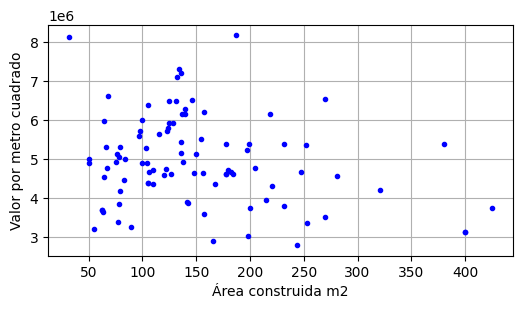

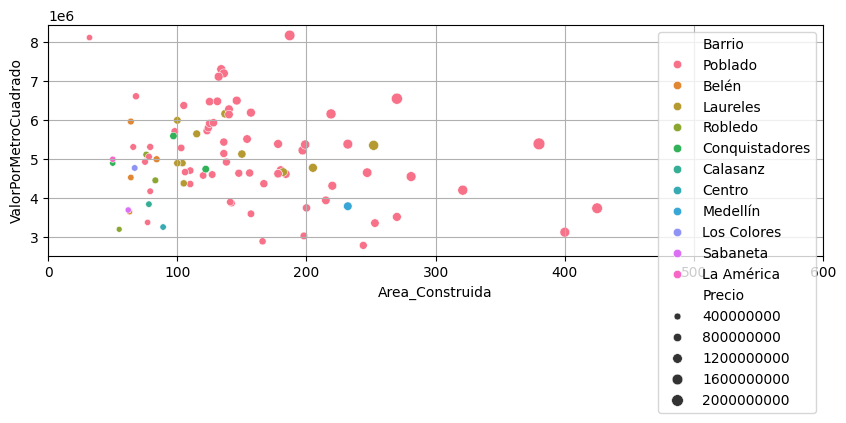

In [ ]:
#Las gráficas de dispersión X,Y son realizables en Pyplot, pero en Seaborn adquieren nuevas dimensiones.
plt.figure(figsize=(6,3))
plt.plot(data['Area_Construida'], data['ValorPorMetroCuadrado'], '.b')
plt.xlabel('Área construida m2')
plt.ylabel('Valor por metro cuadrado')
plt.grid()

plt.figure(figsize=(10,3))
sns.scatterplot(data = data, x = "Area_Construida", y = 'ValorPorMetroCuadrado', size="Precio", hue="Barrio") #hue corresponde a color
plt.grid()
plt.xlim(0,600)

(array([ 7., 11., 10., 23., 16., 10., 10.,  1.,  3.,  2.]),
 array([2786885.24590164, 3326378.53949329, 3865871.83308495,
        4405365.1266766 , 4944858.42026826, 5484351.71385991,
        6023845.00745156, 6563338.30104322, 7102831.59463487,
        7642324.88822653, 8181818.18181818]),
 <BarContainer object of 10 artists>)

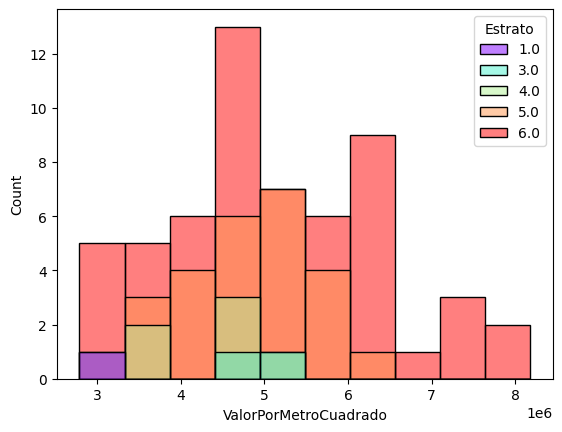

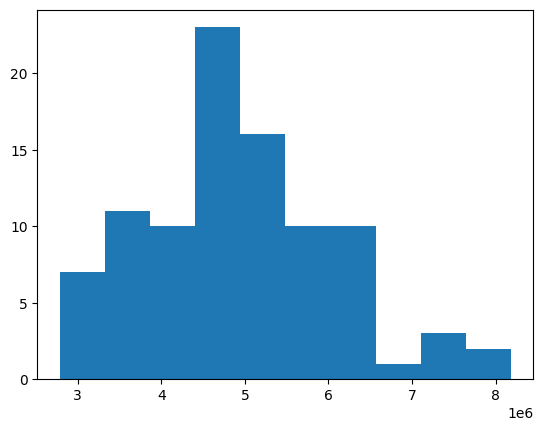

In [ ]:
#Los histogramas permiten visualizar el comportamiento de ciertas variables
sns.histplot(data=data, x="ValorPorMetroCuadrado", bins=10, hue='Estrato', palette='rainbow' )
plt.figure()
plt.hist(data['ValorPorMetroCuadrado'])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Poblado'),
  Text(1, 0, 'Belén'),
  Text(2, 0, 'Laureles'),
  Text(3, 0, 'Robledo'),
  Text(4, 0, 'Conquistadores'),
  Text(5, 0, 'Calasanz'),
  Text(6, 0, 'Centro'),
  Text(7, 0, 'Medellín'),
  Text(8, 0, 'Los Colores'),
  Text(9, 0, 'Sabaneta'),
  Text(10, 0, 'La América')])

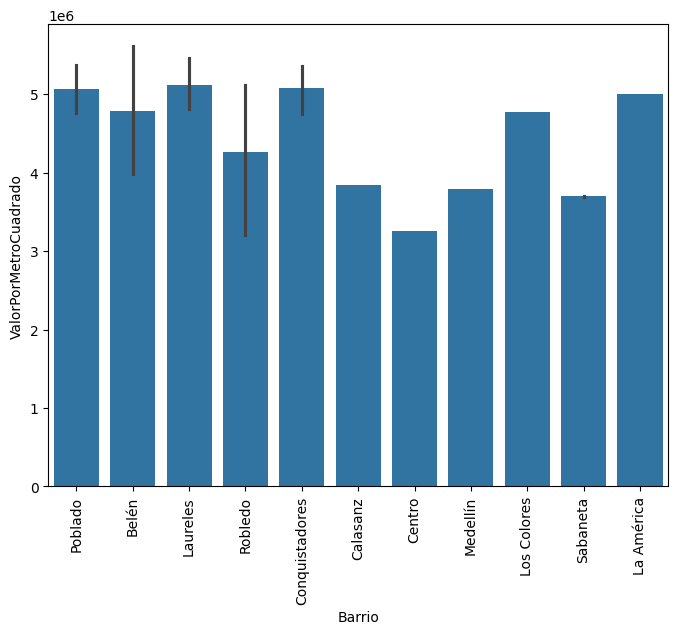

In [ ]:
#Los diagramas de barra
plt.figure(figsize=(8,6))
sns.barplot(x = "Barrio", y = "ValorPorMetroCuadrado", data = data)
plt.xticks(rotation=90)

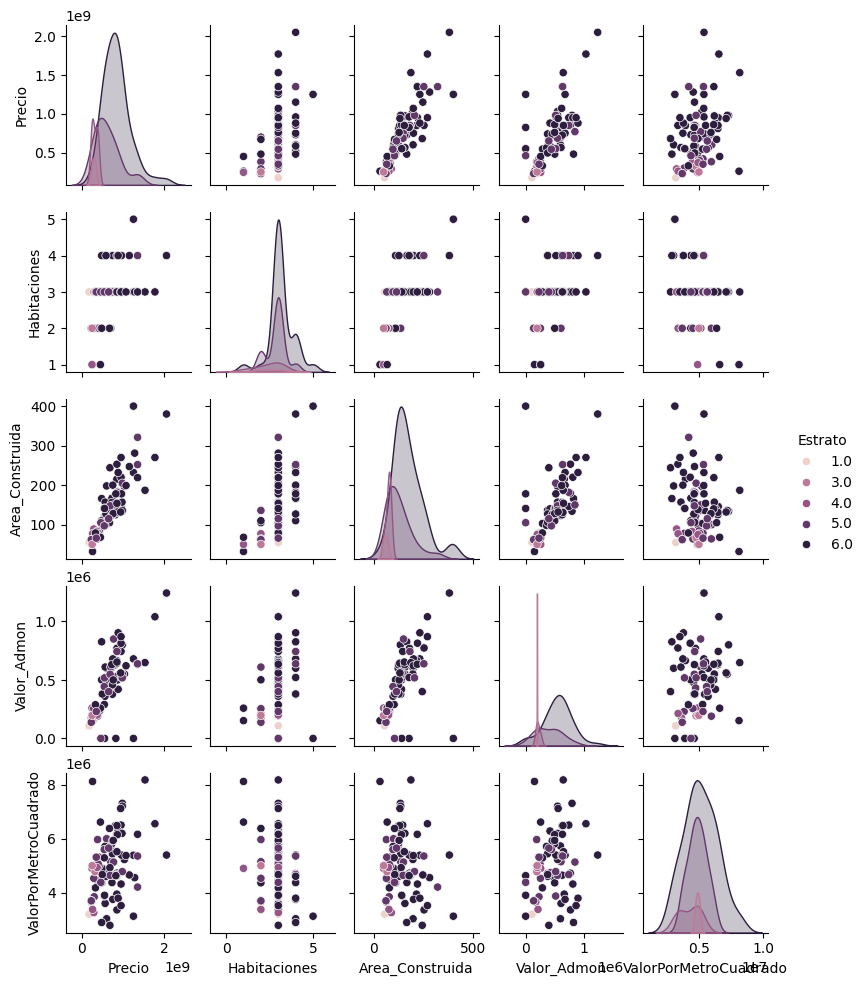

In [ ]:
#Existen otras curvas que permiten comparar diferentes cantidades como la PairPlot
#plt.figure(figsize=(8,8))
data2=data[['Precio', 'Habitaciones', 'Area_Construida','Valor_Admon','ValorPorMetroCuadrado','Estrato']]
sns.pairplot(data2, height=2, aspect=0.8, hue='Estrato')

In [ ]:
#Creemos una tabla que nos calcule el valor promedio de las viviendas de acuerdo con el barrio y la antigüedad.
#Para esto supondremos una filas dadas por el barrio y unas columnas dadas por el valor de la antigüedad.
pt=pd.pivot_table(data=data, index='Barrio', columns='Antiguedad', values='ValorPorMetroCuadrado', aggfunc='mean')
pt=pt.fillna(0)
pt=pt/1e6 #Llevemos los valores a millones.
pt

Antiguedad,Entre 0 y 5 años,Entre 10 y 20 años,Entre 5 y 10 años,Más de 20 años,Remodelado
Barrio,,,,,
Belén,5.484375,0.000000,3.650794,0.000000,4.531250
Calasanz,0.000000,3.846154,0.000000,0.000000,0.000000
Centro,0.000000,0.000000,0.000000,3.258427,0.000000
Conquistadores,5.597938,4.822951,0.000000,0.000000,0.000000
La América,0.000000,0.000000,5.000000,0.000000,0.000000
Laureles,5.197423,5.245238,0.000000,4.725409,0.000000
Los Colores,0.000000,4.776119,0.000000,0.000000,0.000000
Medellín,0.000000,0.000000,0.000000,3.793103,0.000000
Poblado,5.815885,4.332338,5.391325,4.114564,5.014426


<Axes: xlabel='Antiguedad', ylabel='Barrio'>

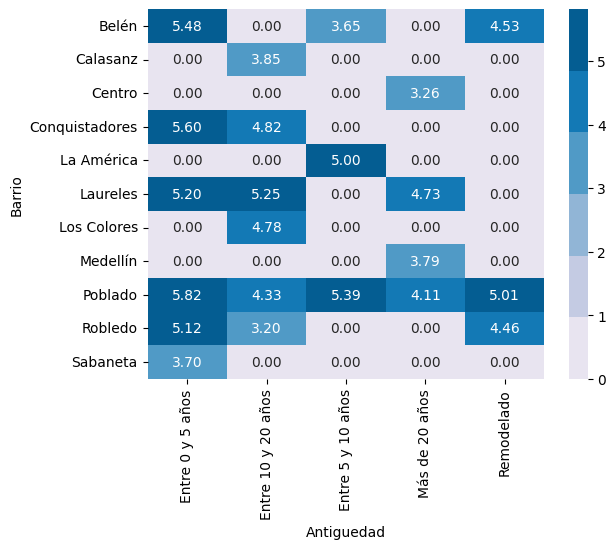

In [ ]:
#Ahora haremos una gráfica de Mapa de Calor, con los datos anteriores.
sns.heatmap(pt, annot=True, fmt='.2f', cmap=sns.color_palette("PuBu"))

#Se pueden mirar otros colores de paletas en la documentación de SeaBorn: https://seaborn.pydata.org/tutorial/color_palettes.html


(array([ 7., 11., 10., 23., 16., 10., 10.,  1.,  3.,  2.]),
 array([2786885.24590164, 3326378.53949329, 3865871.83308495,
        4405365.1266766 , 4944858.42026826, 5484351.71385991,
        6023845.00745156, 6563338.30104322, 7102831.59463487,
        7642324.88822653, 8181818.18181818]),
 <BarContainer object of 10 artists>)

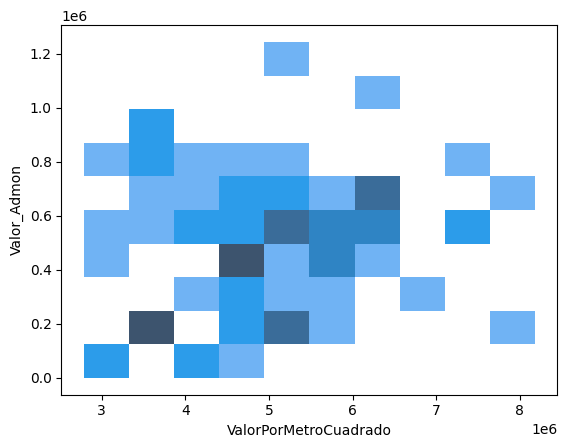

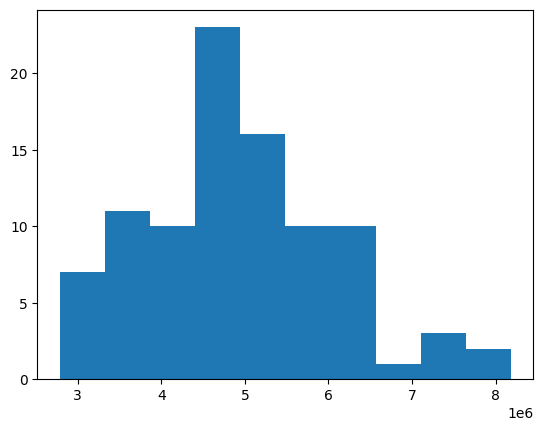

In [ ]:
#Los histogramas permiten visualizar el comportamiento de ciertas variables
sns.histplot(data=data, x="ValorPorMetroCuadrado", y='Valor_Admon', bins=10)#, hue='Estrato', )
plt.figure()
plt.hist(data['ValorPorMetroCuadrado'])

<Axes: xlabel='Antiguedad', ylabel='Barrio'>

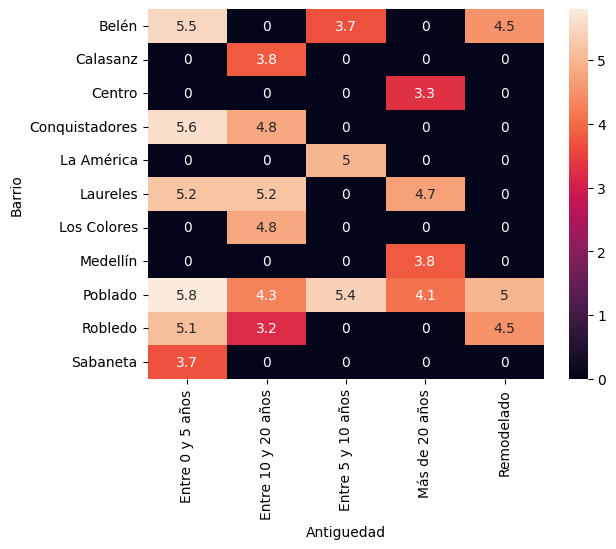

In [ ]:
sns.heatmap(pt.round(decimals=1), annot=True)
